In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# -- Load data --
#df = pd.read_csv('../../data/summary_statistics/bloom_summary_2p_1mad_20260418.csv')
df = pd.read_csv('../../data/summary_statistics/bloom_summary_2p_1mad_20260423.csv')

# Extract year from start date as numeric time variable
df['year'] = pd.to_datetime(df['start']).dt.year

# ============================================================================
# Regression 1: Magnitude vs Time
# ============================================================================
slope_mag, intercept_mag, r_mag, p_mag, se_mag = linregress(df['year'], df['magnitude'])

print('='*60)
print('  Magnitude vs Time')
print('='*60)
print(f'  Slope:     {slope_mag:.6f} mg m-3 yr-1')
print(f'  Intercept: {intercept_mag:.4f}')
print(f'  R²:        {r_mag**2:.4f}')
print(f'  p-value:   {p_mag:.4f}')
print(f'  Std error: {se_mag:.6f}')
print('='*60)

# ============================================================================
# Regression 2: Max Area vs Time
# ============================================================================
df['true_area'] = df['max_area_km2'] + df['max_area_km2'] * df['cloud_pct']/100
slope_area, intercept_area, r_area, p_area, se_area = linregress(df['year'], df['true_area'])

print(f'\n{"="*60}')
print('  Max Area vs Time')
print('='*60)
print(f'  Slope:     {slope_area:.2f} km² yr-1')
print(f'  Intercept: {intercept_area:.2f}')
print(f'  R²:        {r_area**2:.4f}')
print(f'  p-value:   {p_area:.4f}')
print(f'  Std error: {se_area:.2f}')
print('='*60)


  Magnitude vs Time
  Slope:     -0.000673 mg m-3 yr-1
  Intercept: 1.4917
  R²:        0.0218
  p-value:   0.4529
  Std error: 0.000883

  Max Area vs Time
  Slope:     61470.79 km² yr-1
  Intercept: -121957185.31
  R²:        0.3364
  p-value:   0.0012
  Std error: 16931.37


In [2]:
df['true_are'] = df['max_area_km2'] + df['max_area_km2'] * df['cloud_pct']/100

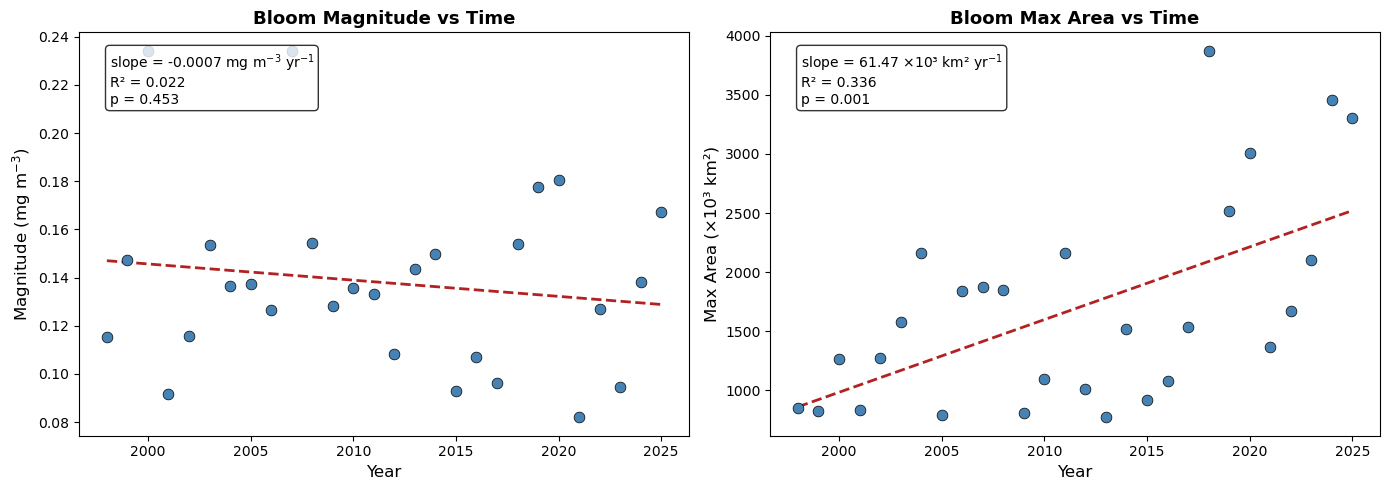


Saved regression results.


In [3]:
# ============================================================================
# Plot
# ============================================================================
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# -- Panel 1: Magnitude --
ax = axs[0]
ax.scatter(df['year'], df['magnitude'], color='steelblue', edgecolor='black',
           linewidth=0.5, s=60, zorder=3)
x_fit = np.array([df['year'].min(), df['year'].max()])
ax.plot(x_fit, intercept_mag + slope_mag * x_fit, color='firebrick',
        linewidth=2, linestyle='--')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Magnitude (mg m$^{-3}$)', fontsize=12)
ax.set_title('Bloom Magnitude vs Time', fontsize=13, fontweight='bold')
ax.text(0.05, 0.95,
        f'slope = {slope_mag:.4f} mg m$^{{-3}}$ yr$^{{-1}}$\n'
        f'R² = {r_mag**2:.3f}\n'
        f'p = {p_mag:.3f}',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# -- Panel 2: Max Area --
ax = axs[1]
ax.scatter(df['year'], df['true_area'] / 1e3, color='steelblue', edgecolor='black',
           linewidth=0.5, s=60, zorder=3)
ax.plot(x_fit, (intercept_area + slope_area * x_fit) / 1e3, color='firebrick',
        linewidth=2, linestyle='--')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Max Area (×10³ km²)', fontsize=12)
ax.set_title('Bloom Max Area vs Time', fontsize=13, fontweight='bold')
ax.text(0.05, 0.95,
        f'slope = {slope_area/1e3:.2f} ×10³ km² yr$^{{-1}}$\n'
        f'R² = {r_area**2:.3f}\n'
        f'p = {p_area:.3f}',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
# plt.savefig('bloom_regression.png', dpi=300, bbox_inches='tight')
plt.show()

# -- Save regression results --
reg_results = pd.DataFrame({
    'response': ['magnitude', 'max_area_km2'],
    'slope': [slope_mag, slope_area],
    'intercept': [intercept_mag, intercept_area],
    'r_squared': [r_mag**2, r_area**2],
    'p_value': [p_mag, p_area],
    'std_error': [se_mag, se_area]
})
reg_results.to_csv('../../data/summary_statistics/bloom_regression_results.csv', index=False)
print('\nSaved regression results.')

  Gamma GLM: Magnitude ~ Year
                 Generalized Linear Model Regression Results                  
Dep. Variable:              magnitude   No. Observations:                   28
Model:                            GLM   Df Residuals:                       26
Model Family:                   Gamma   Df Model:                            1
Link Function:                    Log   Scale:                        0.091104
Method:                          IRLS   Log-Likelihood:                 48.536
Date:                Thu, 23 Apr 2026   Deviance:                       2.3704
Time:                        15:11:18   Pearson chi2:                     2.37
No. Iterations:                     7   Pseudo R-squ. (CS):          0.0001275
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.0436 

/tmp/ipykernel_885991/1231324809.py:61: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  glm_slope_mag = glm_mag_fit.params[1]
/tmp/ipykernel_885991/1231324809.py:62: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  glm_p_mag = glm_mag_fit.pvalues[1]
/tmp/ipykernel_885991/1231324809.py:86: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  glm_slope_area = glm_area_fit.params[1]
/tmp/ipykernel_885991/1231324809.py:87: FutureWarning: Series.__g

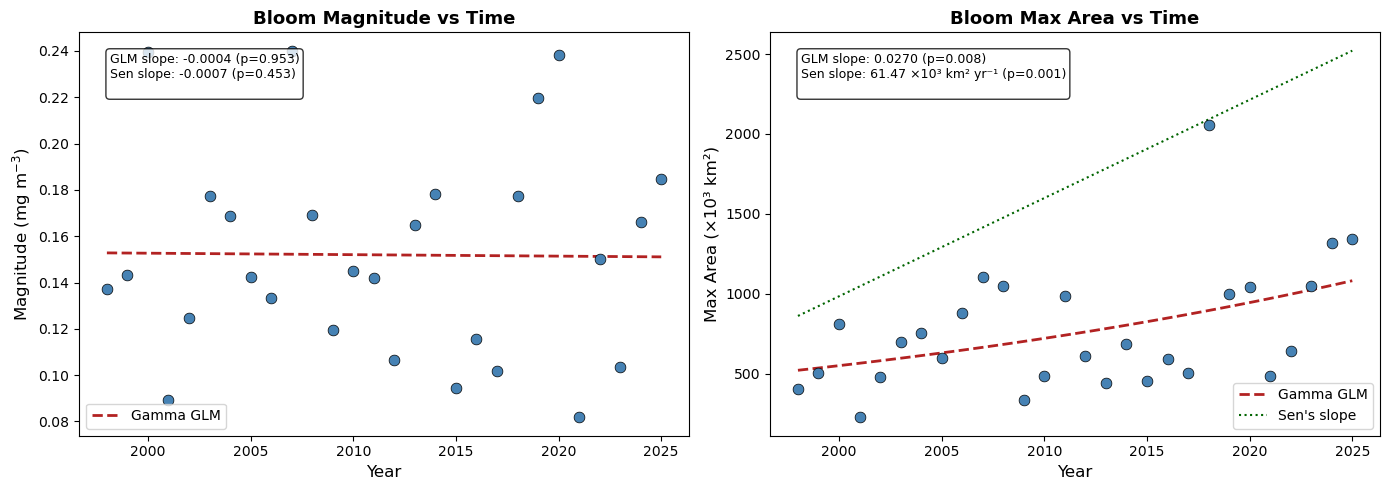

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mstats, kendalltau
import statsmodels.api as sm

# -- Load data --
df = pd.read_csv('../../data/summary_statistics/bloom_summary_2p_1mad_20260418.csv')
df['year'] = pd.to_datetime(df['start']).dt.year

df['true_are'] = df['max_area_km2'] + df['max_area_km2'] * df['cloud_pct']/100

# ============================================================================
# Gamma GLM (log link) — primary model
# ============================================================================

# -- Magnitude --
X_mag = sm.add_constant(df['year'])
glm_mag = sm.GLM(df['magnitude'], X_mag, family=sm.families.Gamma(sm.families.links.Log()))
glm_mag_fit = glm_mag.fit()

print('='*60)
print('  Gamma GLM: Magnitude ~ Year')
print('='*60)
print(glm_mag_fit.summary())

# -- Max Area --
X_area = sm.add_constant(df['year'])
glm_area = sm.GLM(df['true_are'], X_area, family=sm.families.Gamma(sm.families.links.Log()))
glm_area_fit = glm_area.fit()

print(f'\n{"="*60}')
print('  Gamma GLM: Max Area ~ Year')
print('='*60)
print(glm_area_fit.summary())

# ============================================================================
# Plot — Gamma GLM predictions
# ============================================================================
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

x_pred = np.linspace(df['year'].min(), df['year'].max(), 100)
X_pred = sm.add_constant(x_pred)

# -- Panel 1: Magnitude --
ax = axs[0]
ax.scatter(df['year'], df['magnitude'], color='steelblue', edgecolor='black',
           linewidth=0.5, s=60, zorder=3)

# GLM prediction (log link: predict on link scale, then exponentiate)
y_pred_mag = glm_mag_fit.predict(X_pred)
ax.plot(x_pred, y_pred_mag, color='firebrick', linewidth=2, linestyle='--',
        label='Gamma GLM')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Magnitude (mg m$^{-3}$)', fontsize=12)
ax.set_title('Bloom Magnitude vs Time', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# GLM stats
glm_slope_mag = glm_mag_fit.params[1]
glm_p_mag = glm_mag_fit.pvalues[1]
ax.text(0.05, 0.95,
        f'GLM slope: {glm_slope_mag:.4f} (p={glm_p_mag:.3f})\n'
        f'Sen slope: {slope_mag:.4f} (p={p_mag:.3f})\n',
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# -- Panel 2: Max Area --
ax = axs[1]
ax.scatter(df['year'], df['true_are'] / 1e3, color='steelblue', edgecolor='black',
           linewidth=0.5, s=60, zorder=3)

y_pred_area = glm_area_fit.predict(X_pred)
ax.plot(x_pred, y_pred_area / 1e3, color='firebrick', linewidth=2, linestyle='--',
        label='Gamma GLM')

ax.plot(x_pred, (intercept_area + slope_area * x_pred) / 1e3, color='darkgreen',
        linewidth=1.5, linestyle=':', label="Sen's slope")

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Max Area (×10³ km²)', fontsize=12)
ax.set_title('Bloom Max Area vs Time', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

glm_slope_area = glm_area_fit.params[1]
glm_p_area = glm_area_fit.pvalues[1]
ax.text(0.05, 0.95,
        f'GLM slope: {glm_slope_area:.4f} (p={glm_p_area:.3f})\n'
        f'Sen slope: {slope_area/1e3:.2f} ×10³ km² yr⁻¹ (p={p_area:.3f})\n',
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
#plt.savefig('bloom_regression_gamma.png', dpi=300, bbox_inches='tight')
plt.show()